# exp08_multihorizonte — pronóstico t+1 … t+24 horas OPERATIVAS

Modelo DIRECTO único (horizonte como feature) sobre el bloque 5×5 (25 nodos). El
horizonte h = h-ésima hora **operativa** futura; el target `kt(τ_h)` siempre está
definido. Persistence de referencia = kt(t) (último operativo), igual para toda h.

Reproducir: `from forecasting import multihorizonte as MH;
MH.ejecutar(lista_de_nodos)`. Evaluación rica: global, por horizonte, hora (local),
mes, nodo, régimen, fill_flag y rangos.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from forecasting import config as C

D = os.path.join(C.DIR_EXPERIMENTS, 'exp08_multihorizonte', 'v1')
cargar = lambda n: pd.read_csv(os.path.join(D, n))
g = cargar('desglose_global.csv').iloc[0]
print('GLOBAL (test): RMSE %.1f vs persist %.1f | skill %.4f | R2 %.3f | n %d' % (
    g.RMSE_modelo, g.RMSE_persistence, g.skill, g.R2_modelo, g.n))

GLOBAL (test): RMSE 139.4 vs persist 184.4 | skill 0.2440 | R2 0.774 | n 2466540


## Skill y RMSE por HORIZONTE

El valor del modelo CRECE con el horizonte: persistence colapsa al alejarse. En h=1
el modelo global no se especializa (skill <0); para h=1 conviene el modelo t+1 dedicado.

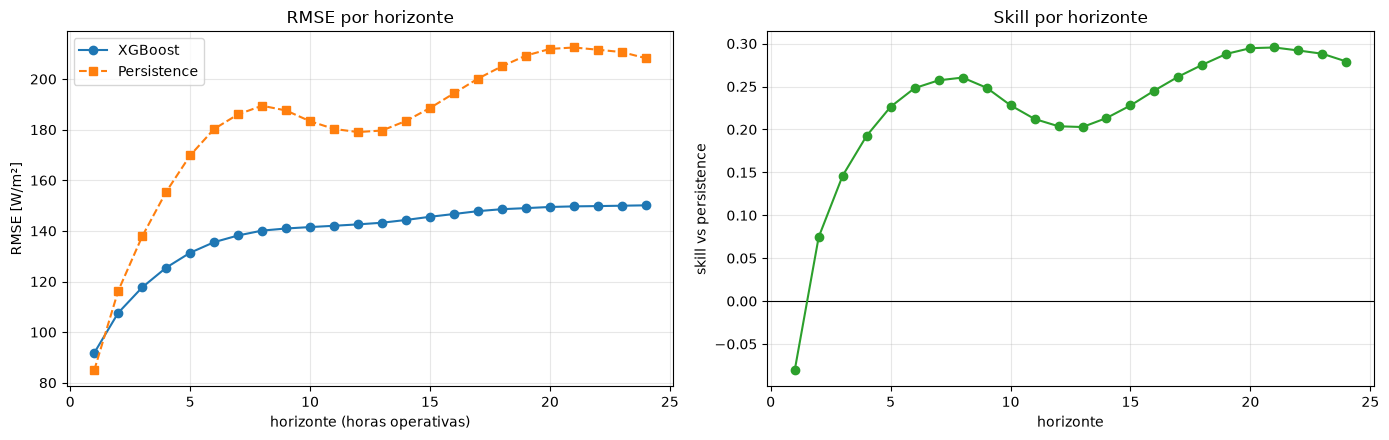

,horizonte,RMSE_modelo,RMSE_persistence,skill,R2_modelo
0,1,91.751,84.901,-0.081,0.902
2,3,117.681,137.823,0.146,0.839
5,6,135.554,180.284,0.248,0.787
11,12,142.579,179.049,0.204,0.764
17,18,148.578,205.043,0.275,0.744
23,24,150.104,208.228,0.279,0.738


In [2]:
h = cargar('desglose_horizonte.csv')
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(h.horizonte, h.RMSE_modelo, 'o-', label='XGBoost')
ax[0].plot(h.horizonte, h.RMSE_persistence, 's--', color='tab:orange', label='Persistence')
ax[0].set_xlabel('horizonte (horas operativas)'); ax[0].set_ylabel('RMSE [W/m²]')
ax[0].legend(); ax[0].grid(alpha=0.3); ax[0].set_title('RMSE por horizonte')
ax[1].axhline(0, color='k', lw=0.8)
ax[1].plot(h.horizonte, h.skill, 'o-', color='tab:green')
ax[1].set_xlabel('horizonte'); ax[1].set_ylabel('skill vs persistence')
ax[1].grid(alpha=0.3); ax[1].set_title('Skill por horizonte')
plt.tight_layout(); plt.show()
display(h[h.horizonte.isin([1,3,6,12,18,24])][['horizonte','RMSE_modelo','RMSE_persistence','skill','R2_modelo']].round(3))

## Mapa de calor skill por HORA local × HORIZONTE

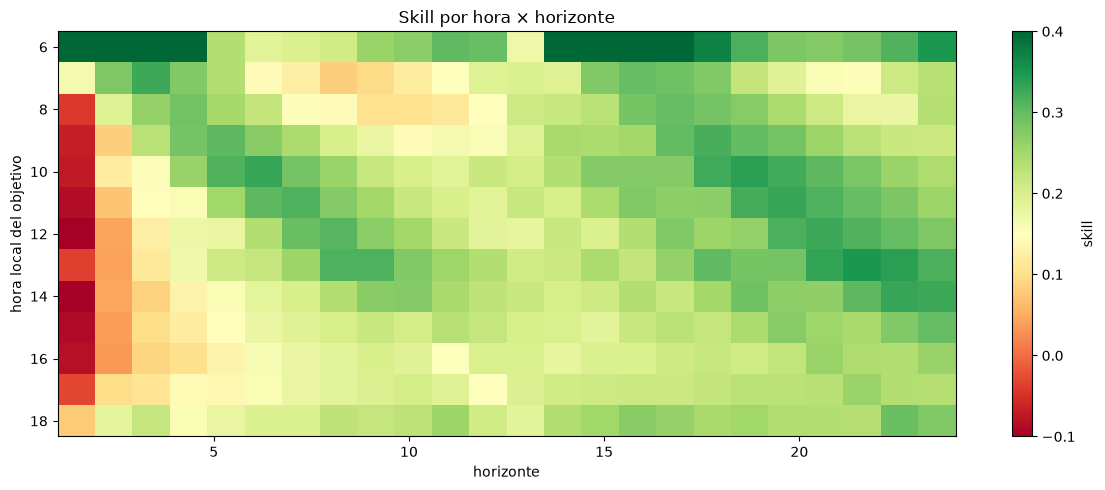

In [3]:
hm = pd.read_csv(os.path.join(D, 'heatmap_hora_horizonte.csv'), index_col=0)
fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(hm.values, aspect='auto', cmap='RdYlGn', vmin=-0.1, vmax=0.4,
               extent=[hm.columns.astype(int).min(), hm.columns.astype(int).max(),
                       hm.index.max()+0.5, hm.index.min()-0.5])
fig.colorbar(im, ax=ax, label='skill'); ax.set_xlabel('horizonte'); ax.set_ylabel('hora local del objetivo')
ax.set_title('Skill por hora × horizonte'); plt.tight_layout(); plt.show()

## Por MES, por HORA local y por NODO

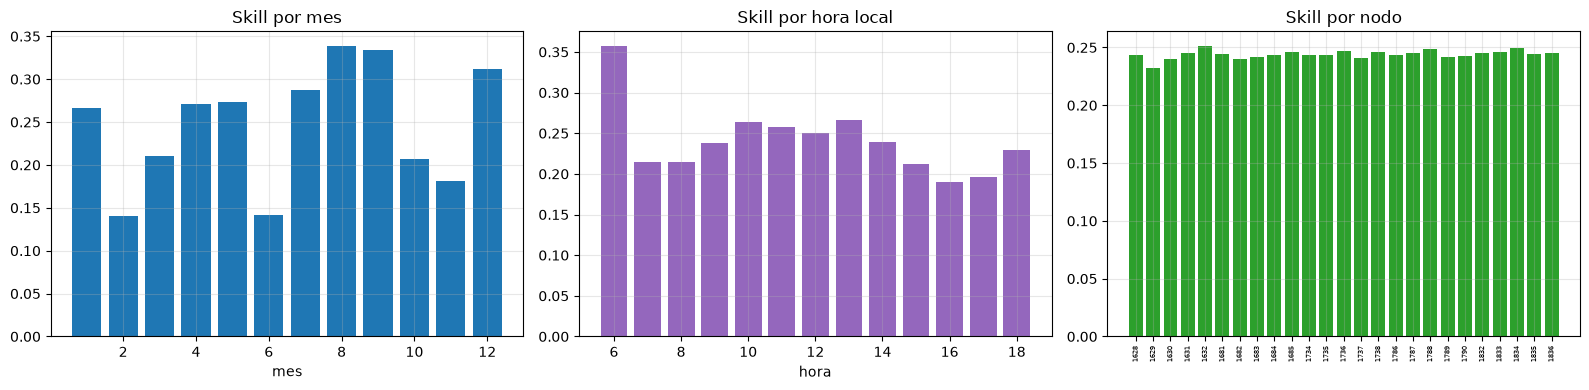

In [4]:
mes = cargar('desglose_mes.csv'); hora = cargar('desglose_hora.csv'); nodo = cargar('desglose_nodo.csv')
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
ax[0].bar(mes.mes_target, mes.skill, color='tab:blue'); ax[0].set_title('Skill por mes'); ax[0].set_xlabel('mes')
ax[1].bar(hora.hora_target, hora.skill, color='tab:purple'); ax[1].set_title('Skill por hora local'); ax[1].set_xlabel('hora')
ax[2].bar(nodo.nodo_id.astype(str), nodo.skill, color='tab:green'); ax[2].set_title('Skill por nodo'); ax[2].tick_params(axis='x', rotation=90, labelsize=5)
for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Régimen, fill_flag y RANGOS (min/media/max del skill por corte)

In [5]:
display(cargar('desglose_regimen.csv').round(3))
display(cargar('desglose_fill_flag.csv').round(3))
display(cargar('desglose_rangos.csv').round(3))

,regimen_nubosidad,n,RMSE_modelo,RMSE_persistence,MAE_modelo,MBE_modelo,R2_modelo,skill
0,cubierto (kt<0.3),175421,338.407,314.708,295.409,295.337,-26.082,-0.075
1,parcial (0.3-0.7),429073,170.868,206.343,130.255,125.657,0.009,0.172
2,despejado (kt>=0.7),1862046,90.757,160.998,69.820,-54.798,0.891,0.436


,segmento,n,RMSE_modelo,RMSE_persistence,MAE_modelo,MBE_modelo,R2_modelo,skill
0,limpio_ff0,2240600,143.470,190.321,101.003,-0.159,0.743,0.246
1,rellenado_ff_pos,225940,90.084,110.296,50.503,17.904,0.783,0.183


,por,metrica,min,media,max,argmin,argmax
0,horizonte,skill,-0.081,0.224,0.295,1,21
1,hora_target,skill,0.190,0.241,0.357,16,6
2,mes_target,skill,0.140,0.247,0.339,2,8
3,nodo_id,skill,0.233,0.244,0.251,1629,1632


## Importancia de features (incluye horizonte y gap_horas)

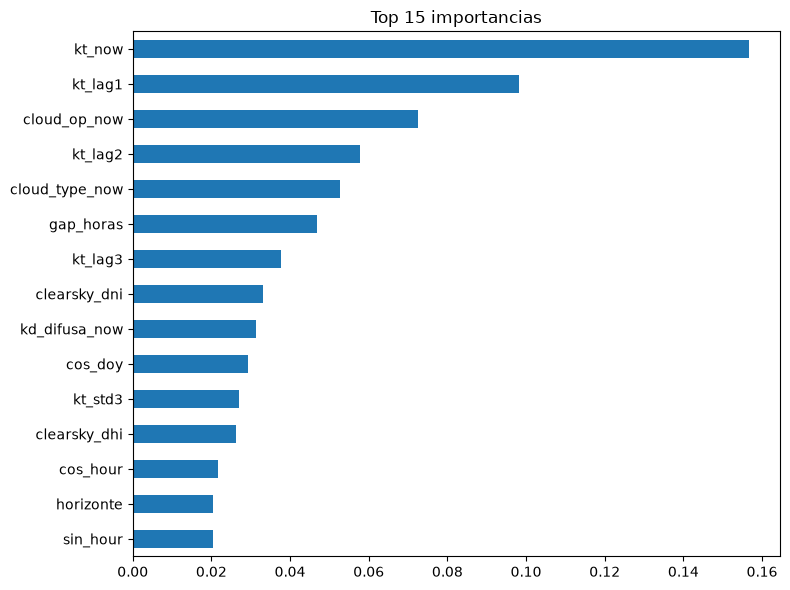

In [6]:
imp = pd.read_csv(os.path.join(D, 'feature_importance.csv'), index_col=0)
fig, ax = plt.subplots(figsize=(8, 6))
imp['gain'].head(15)[::-1].plot.barh(ax=ax); ax.set_title('Top 15 importancias')
plt.tight_layout(); plt.show()